# 04  -  Drift Detection

Monitor whether the input feature distribution has shifted since training.
- **PSI (Population Stability Index)**: compares binned distributions between train and new data.
- **KS test (Kolmogorov-Smirnov)**: non-parametric test for distribution equality per feature.

Drift matters because an XGBoost model trained on August data will degrade if September VMs have fundamentally different usage patterns.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
DATA = Path("../data/clean")

## 1. Load features from training and "production" windows

We simulate a production shift by splitting our VM population: the first 80% (sorted by instance) represents the training distribution, and the last 20% represents new incoming VMs.

In [2]:
daily = pd.read_csv(DATA / "vm_cpu_daily.csv")
dates = daily.columns[1:].tolist()
TRAIN_DAYS = 25
train_dates = dates[:TRAIN_DAYS]

train_vals = daily[train_dates].values.astype(float)
valid_mask = ~np.isnan(train_vals).all(axis=1)
train_vals = train_vals[valid_mask]
instances = daily.loc[valid_mask, "instance"].to_numpy()

def build_features(matrix):
    n = matrix.shape[0]
    feats = np.zeros((n, 5))
    for i in range(n):
        row = matrix[i]
        row = row[~np.isnan(row)]
        if len(row) == 0:
            continue
        feats[i, 0] = np.std(row)
        feats[i, 1] = np.min(row)
        feats[i, 2] = np.median(row)
        if len(row) > 1:
            feats[i, 3] = np.polyfit(range(len(row)), row, 1)[0]
        mean = np.mean(row)
        feats[i, 4] = feats[i, 0] / mean if mean > 0 else 0
    return feats

feature_names = ["std", "min", "p50", "trend", "cv"]
X_all = build_features(train_vals)

# Split: 80% "reference" (train), 20% "production" (new)
split = int(len(X_all) * 0.8)
X_ref = X_all[:split]
X_prod = X_all[split:]
print(f"Reference (train): {len(X_ref):,} VMs")
print(f"Production (new):  {len(X_prod):,} VMs")

Reference (train): 84,961 VMs
Production (new):  21,241 VMs


## 2. PSI (Population Stability Index)

PSI measures how much a feature's distribution has shifted between two populations.
- PSI < 0.1: no significant shift
- 0.1 < PSI < 0.25: moderate shift, investigate
- PSI > 0.25: significant shift, model may need retraining

In [3]:
def compute_psi(reference, production, n_bins=10):
    """Population Stability Index between two 1D arrays."""
    breakpoints = np.percentile(reference, np.linspace(0, 100, n_bins + 1))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf
    # Remove duplicate breakpoints
    breakpoints = np.unique(breakpoints)

    ref_counts = np.histogram(reference, bins=breakpoints)[0] + 1
    prod_counts = np.histogram(production, bins=breakpoints)[0] + 1

    ref_pct = ref_counts / ref_counts.sum()
    prod_pct = prod_counts / prod_counts.sum()

    psi = np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct))
    return psi

print("PSI per feature (reference vs production):")
psi_results = []
for i, name in enumerate(feature_names):
    psi = compute_psi(X_ref[:, i], X_prod[:, i])
    status = "OK" if psi < 0.1 else "WARN" if psi < 0.25 else "ALERT"
    psi_results.append({"feature": name, "psi": psi, "status": status})
    print(f"  {name:>6}: PSI = {psi:.4f}  [{status}]")

df_psi = pd.DataFrame(psi_results)

PSI per feature (reference vs production):
     std: PSI = 0.0005  [OK]
     min: PSI = 0.0003  [OK]
     p50: PSI = 0.0004  [OK]
   trend: PSI = 0.0008  [OK]
      cv: PSI = 0.0007  [OK]


## 3. KS test per feature

Two-sample Kolmogorov-Smirnov test: null hypothesis is that reference and production come from the same distribution. A low p-value rejects the null (drift detected).

In [4]:
print("KS test per feature:")
ks_results = []
for i, name in enumerate(feature_names):
    stat, pval = stats.ks_2samp(X_ref[:, i], X_prod[:, i])
    drift = "DRIFT" if pval < 0.05 else "OK"
    ks_results.append({"feature": name, "ks_stat": stat, "p_value": pval, "drift": drift})
    print(f"  {name:>6}: KS = {stat:.4f}, p = {pval:.2e}  [{drift}]")

df_ks = pd.DataFrame(ks_results)

KS test per feature:
     std: KS = 0.0071, p = 3.51e-01  [OK]
     min: KS = 0.0064, p = 4.82e-01  [OK]
     p50: KS = 0.0071, p = 3.55e-01  [OK]
   trend: KS = 0.0053, p = 7.20e-01  [OK]
      cv: KS = 0.0053, p = 7.19e-01  [OK]


## 4. Distribution comparison plots

Overlay reference vs production histograms for each feature to visualize any shift.

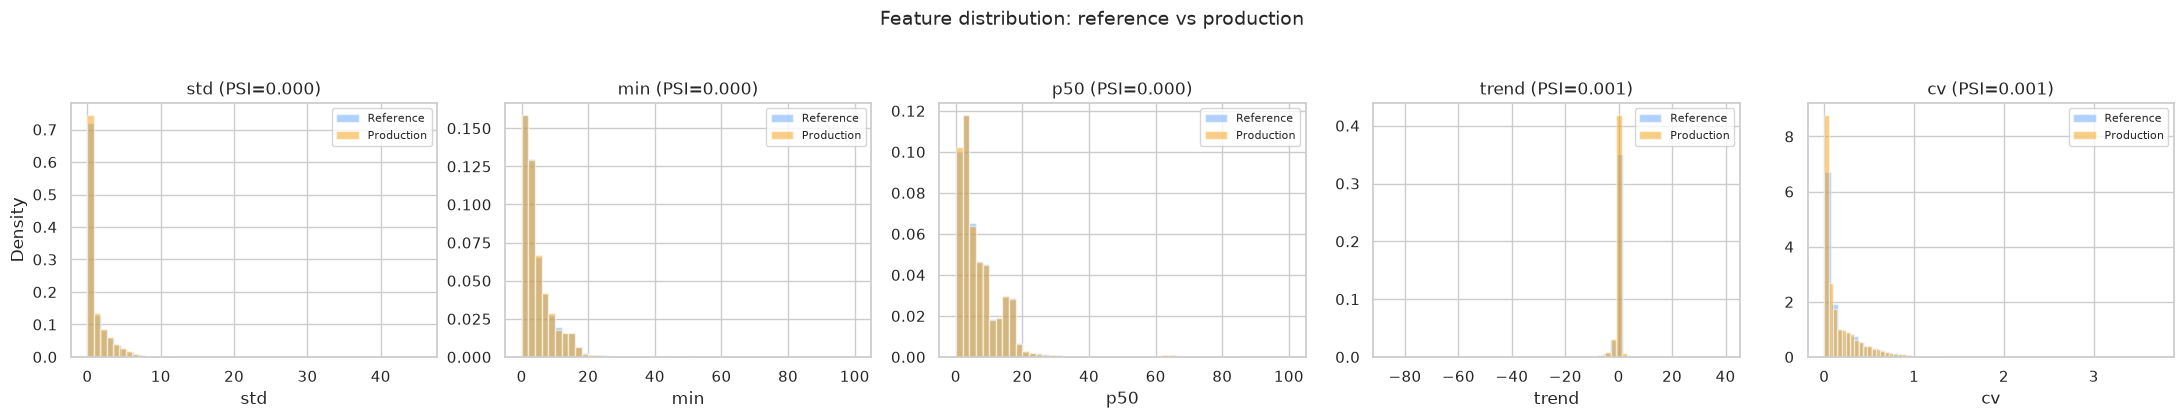

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, i, name in zip(axes, range(5), feature_names):
    ax.hist(X_ref[:, i], bins=50, alpha=0.5, density=True, label="Reference", color="#60A5FA")
    ax.hist(X_prod[:, i], bins=50, alpha=0.5, density=True, label="Production", color="#F59E0B")
    psi_val = df_psi.loc[df_psi["feature"] == name, "psi"].values[0]
    ax.set_title(f"{name} (PSI={psi_val:.3f})")
    ax.set_xlabel(name)
    if i == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Feature distribution: reference vs production", fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig("../reports/figures/drift_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

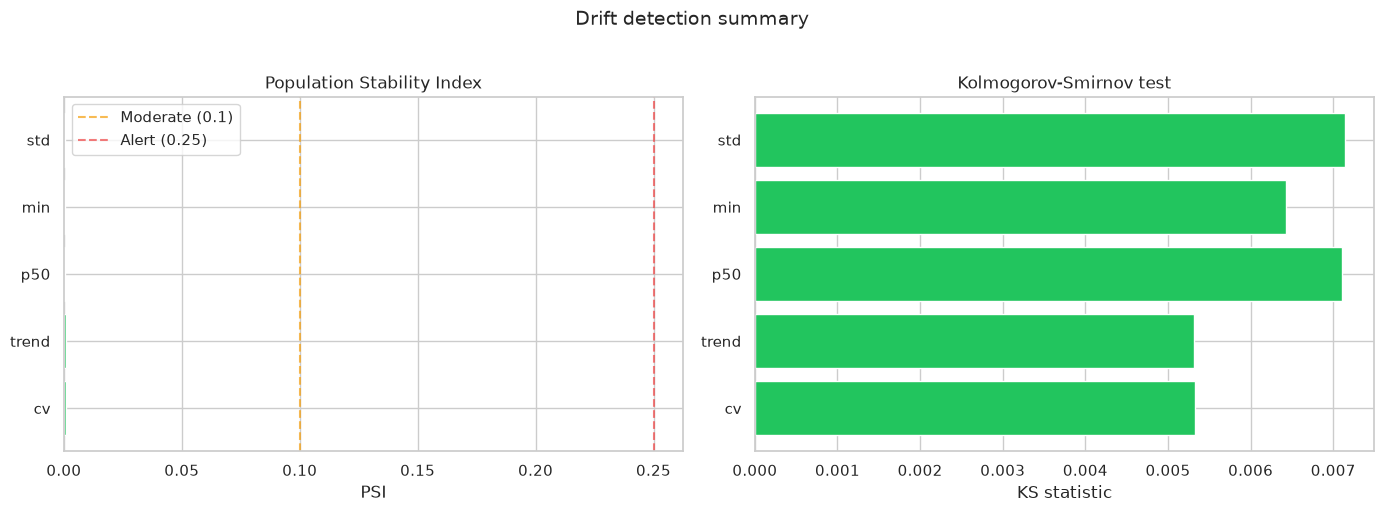


Interpretation:
If PSI < 0.1 and KS p > 0.05 for all features, the model is safe to use as-is.
If any feature shows drift, investigate whether retraining is needed.
In production, run this check weekly or on every new data batch.


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PSI bar chart
colors_psi = ["#22C55E" if s == "OK" else "#F59E0B" if s == "WARN" else "#EF4444" for s in df_psi["status"]]
ax1.barh(df_psi["feature"], df_psi["psi"], color=colors_psi, edgecolor="white")
ax1.axvline(0.1, color="#F59E0B", linestyle="--", alpha=0.7, label="Moderate (0.1)")
ax1.axvline(0.25, color="#EF4444", linestyle="--", alpha=0.7, label="Alert (0.25)")
ax1.set_xlabel("PSI")
ax1.set_title("Population Stability Index")
ax1.legend()
ax1.invert_yaxis()

# KS statistic bar chart
colors_ks = ["#EF4444" if d == "DRIFT" else "#22C55E" for d in df_ks["drift"]]
ax2.barh(df_ks["feature"], df_ks["ks_stat"], color=colors_ks, edgecolor="white")
ax2.set_xlabel("KS statistic")
ax2.set_title("Kolmogorov-Smirnov test")
ax2.invert_yaxis()

plt.suptitle("Drift detection summary", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/drift_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("If PSI < 0.1 and KS p > 0.05 for all features, the model is safe to use as-is.")
print("If any feature shows drift, investigate whether retraining is needed.")
print("In production, run this check weekly or on every new data batch.")